## Business Context

A sales forecast predicts future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action. Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. 

An accurate sales forecast process has many benefits, which include improved decision-making about the future and the reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establishes benchmarks that can be used to assess trends in the future.

## Objective

They hired you as an MLOps Engineer, and your task is to build an automated MLOps pipeline with CI/CD to deliver accurate and reliable sales forecasts. The objective is to leverage historical sales data, industry trends, and the current pipeline status to predict weekly, monthly, quarterly, and annual revenues. By automating data ingestion, preprocessing, model training, evaluation, and deployment, the pipeline will ensure scalability, consistency, and minimal manual intervention. With CI/CD integration, forecasts will be continuously updated and seamlessly deployed, enabling different business verticals to plan sales operations by region, optimize supply chain procurement, reduce risks in sales pipelines, and establish benchmarks for future trend analysis. Ultimately, this solution will enhance decision-making, streamline planning efforts, and drive operational efficiency and business growth.

## Data Dictionary

The data contains the different attributes of the various products and stores.

- **Product_Id**: Unique identifier of each product, each identifier having two letters at the beginning, followed by a number
- **Product_Weight**: Weight of each product
- **Product_Sugar_Content**: Sugar content of each product, like low sugar, regular, and no sugar
- **Product_Allocated_Area**: Ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type**: Broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP**: Maximum retail price of each product
- **Store_Id**: Unique identifier of each store
- **Store_Establishment_Year**: Year in which the store was established
- **Store_Size**: Size of the store, depending on sq. feet, like high, medium, and low
- **Store_Location_City_Type**: Type of city in which the store is located, like Tier 1, Tier 2, and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than that of its Tier 2 and Tier 3 counterparts
- **Store_Type**: Type of store depending on the products that are being sold there, like Departmental Store, Supermarket Type 1, Supermarket Type 2, and Food Mart
- **Product_Store_Sales_Total**: Total revenue generated by the sale of that particular product in that particular store

# Sales Forecast Model Training Pipeline

This notebook walks through the complete process of building and deploying a sales forecast model. Load data from Hugging Face, preprocess it, train a machine learning model, and set up automated CI/CD to keep the model updated. 

In [ ]:
from datasets import load_dataset
import pandas as pd

# Load the sales forecast dataset from Hugging Face Hub
dataset = load_dataset("AngadSi/sales-forecast-dataset")

## 1. Load Dataset from Hugging Face

I am Starting by loading the dataset. Hugging Face Hub is used here to centralize data storage and make it easily accessible.

In [ ]:
# Convert dataset to pandas dataframe for easier manipulation
df = dataset["train"].to_pandas()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8763, 12)


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


## 2. Explore and Understand Data

Convert to pandas & analyzing data

In [12]:
df.isnull().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

Quick check for any missing data that might affect our model.

In [ ]:
# Remove product and store IDs as they are unique identifiers
df_cleaned = df.drop(columns=["Product_Id", "Store_Id"])

## 3. Data Preprocessing

Clean up the data by dropping ID columns - they're unique identifiers and don't help predict sales.

In [ ]:
import datetime

# Calculate store age from establishment year
current_year = datetime.datetime.now().year
df_cleaned["Store_Age"] = current_year - df_cleaned["Store_Establishment_Year"]

# Remove the original establishment year column
df_cleaned.drop("Store_Establishment_Year", axis=1, inplace=True)

## 4. Feature Engineering

Turn raw data into meaningful features. For example, we create a "Store_Age" feature - newer vs older stores might have different sales patterns.

In [15]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Weight             8763 non-null   float64
 1   Product_Sugar_Content      8763 non-null   str    
 2   Product_Allocated_Area     8763 non-null   float64
 3   Product_Type               8763 non-null   str    
 4   Product_MRP                8763 non-null   float64
 5   Store_Size                 8763 non-null   str    
 6   Store_Location_City_Type   8763 non-null   str    
 7   Store_Type                 8763 non-null   str    
 8   Product_Store_Sales_Total  8763 non-null   float64
 9   Store_Age                  8763 non-null   int64  
dtypes: float64(4), int64(1), str(5)
memory usage: 1.1 MB


Verify the cleaned data is ready for modeling.

In [ ]:
from sklearn.model_selection import train_test_split

# Prepare features and target variable
X = df_cleaned.drop("Product_Store_Sales_Total", axis=1)
y = df_cleaned["Product_Store_Sales_Total"]

# I am Spliting data into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7010, 9)
Test shape: (1753, 9)


## 5. Train-Test Split

Divide the data into training and test sets so we can train on one set and evaluate on unseen data.

In [ ]:
# Save processed train and test data
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

train_df.to_csv("data/processed/train.csv", index=False)
test_df.to_csv("data/processed/test.csv", index=False)

## 6. Save Processed Data

Save the cleaned data to CSV for reproducibility and also upload it to Hugging Face.

In [ ]:
from huggingface_hub import login
import os

# Get authentication token for Hugging Face
HF_TOKEN = os.getenv('HF_TOKEN')
if not HF_TOKEN:
    print('HF_TOKEN not set in environment')
    print('Set it locally: export HF_TOKEN="your_token_here"')
    print('Or in Jupyter: %env HF_TOKEN=your_token_here')
else:
    login(token=HF_TOKEN)
    print('Successfully logged in to Hugging Face')

## 7. Authentication and Data Upload

Connect to Hugging Face using the token and upload the processed datasets. This centralizes the data and makes it available for the automated pipeline.

In [ ]:
from huggingface_hub import HfApi

# Upload processed data to Hugging Face dataset
api = HfApi()

api.upload_file(
    path_or_fileobj="data/processed/train.csv",
    path_in_repo="train.csv",
    repo_id="AngadSi/sales-forecast-dataset",
    repo_type="dataset"
)

api.upload_file(
    path_or_fileobj="data/processed/test.csv",
    path_in_repo="test.csv",
    repo_id="AngadSi/sales-forecast-dataset",
    repo_type="dataset"
)

CommitInfo(commit_url='https://huggingface.co/datasets/AngadSi/sales-forecast-dataset/commit/2b9104c303b1ac6ad5a4ad4dc6f47ff88056455c', commit_message='Upload test.csv with huggingface_hub', commit_description='', oid='2b9104c303b1ac6ad5a4ad4dc6f47ff88056455c', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/AngadSi/sales-forecast-dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='AngadSi/sales-forecast-dataset'), pr_revision=None, pr_num=None)

## 8. Load Processed Data

Reload the data from Hugging Face to use in our model. This simulates what the automated pipeline will do.

In [ ]:
import pandas as pd

# Load the processed data from Hugging Face dataset
train_url = "https://huggingface.co/datasets/AngadSi/sales-forecast-dataset/resolve/main/train.csv"
test_url = "https://huggingface.co/datasets/AngadSi/sales-forecast-dataset/resolve/main/test.csv"

train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

print(train_df.shape, test_df.shape)

(7010, 10) (1753, 10)


## 9. Prepare Features and Target

Separate what we're predicting (sales) from what we're using to predict (product and store info).

In [ ]:
# Separate features and target variable
X_train = train_df.drop("Product_Store_Sales_Total", axis=1)
y_train = train_df["Product_Store_Sales_Total"]

X_test = test_df.drop("Product_Store_Sales_Total", axis=1)
y_test = test_df["Product_Store_Sales_Total"]

## 10. Build Preprocessing Pipeline

Set up a pipeline that automatically scales numbers and encodes categorical variables. This way, all transformations happen consistently.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

C:\Users\geek9\AppData\Local\Temp\ipykernel_46628\553342827.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


This configuration ensures numerical data is normalized and categorical data is properly encoded.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Create model pipeline
model = RandomForestRegressor(random_state=42)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

# Define hyperparameters to test
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

## 11. Initialize and Configure Machine Learning Model

Set up a Random Forest model with different hyperparameters to try out. Random Forests work well for regression problems like sales forecasting.

In [ ]:
from sklearn.model_selection import GridSearchCV

# I am doing optimization using grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Train the model
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}


## 12. Train Model with Hyperparameter Tuning

Use GridSearchCV to test different combinations of hyperparameters and find what works best. This automatically finds the best settings for our Random Forest.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on test set
y_pred = best_model.predict(X_test)

# Calculate performance metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 280.34676041635015
MAE: 106.86899621435438
R2 Score: 0.9311192560194044


## 13. Model Evaluation

Check how well our model performs on the test set using RMSE (prediction error), MAE (average error), and R² (how much variance it explains).

In [ ]:
import joblib

# Save the trained model to disk
joblib.dump(best_model, "sales_forecast_model.pkl")

['sales_forecast_model.pkl']

## 14. Save Trained Model

Save the trained model as a pickle file so we can use it in production without retraining.

In [ ]:
from huggingface_hub import create_repo, HfApi

# Create model repository on Hugging Face 
create_repo("AngadSi/sales-forecast-model", repo_type="model", exist_ok=True)

# Upload the trained model to Hugging Face
api = HfApi()

api.upload_file(
    path_or_fileobj="sales_forecast_model.pkl",
    path_in_repo="sales_forecast_model.pkl",
    repo_id="AngadSi/sales-forecast-model",
    repo_type="model"
)

Processing Files (1 / 1): 100%|██████████| 50.0MB / 50.0MB, 31.3MB/s  
New Data Upload: 100%|██████████| 50.0MB / 50.0MB, 31.3MB/s  


CommitInfo(commit_url='https://huggingface.co/AngadSi/sales-forecast-model/commit/fb18a6a64780b6fc93b4f4756c8ba44c0a33596b', commit_message='Upload sales_forecast_model.pkl with huggingface_hub', commit_description='', oid='fb18a6a64780b6fc93b4f4756c8ba44c0a33596b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/AngadSi/sales-forecast-model', endpoint='https://huggingface.co', repo_type='model', repo_id='AngadSi/sales-forecast-model'), pr_revision=None, pr_num=None)

## 15. Register and Deploy Model to Hugging Face Hub

Push the model to Hugging Face so it's centralized and accessible for our Streamlit app and future updates.

```dockerfile
FROM python:3.11

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY streamlit_app.py .
COPY sales_forecast_model.pkl .

EXPOSE 7860

CMD ["streamlit", "run", "streamlit_app.py", "--server.port=7860", "--server.address=0.0.0.0"]
```

**Why this approach:**
- **Efficient**: Python 3.11 is smaller and faster than older versions
- **Smart layering**: Cache pip installs separately so we don't reinstall everything on code changes
- **Zero cold start**: Model is inside the container, no download delays
- **Compatible**: Port 7860 is what Hugging Face expects
- **Lean images**: --no-cache-dir removes unnecessary files
- **Reproducible**: Dependencies pinned ensures we can rebuild later

## 17. Deployment Strategy: Docker Containerization

### Production-Ready Container Image

Docker ensures the app runs the same way everywhere - local machine, GitHub Actions, or Hugging Face Spaces. Bundle the model, app code, and all dependencies in a single container.

**Container setup:**
- **Base**: Python 3.11 for ML
- **Model included**: No need to download at runtime
- **Port 7860**: Standard for Hugging Face Spaces
- **Dependencies cached**: Builds are fast

### Dockerfile Configuration

```yaml
name: Sales Forecast ML Pipeline

# Trigger on push to main branch and manual dispatch
on:
  push:
    branches:
      - main
  workflow_dispatch:  # Allow manual trigger from GitHub UI

jobs:
  train-and-upload:
    runs-on: ubuntu-latest
    
    steps:
      - name: Checkout Repository
        uses: actions/checkout@v3
      
      - name: Setup Python
        uses: actions/setup-python@v4
        with:
          python-version: '3.11'
          cache: 'pip'
      
      - name: Install Dependencies
        run: |
          echo "Installing required packages..."
          python -m pip install --upgrade pip
          pip install -r requirements.txt
          echo "Dependencies installed"
      
      - name: Train Model
        env:
          N_JOBS: 1
        run: |
          echo "Starting model training..."
          python train.py
          echo "Training completed"
      
      - name: Verify Model File
        run: |
          if [ -f "sales_forecast_model.pkl" ]; then
            echo "Model file verified"
            ls -lh sales_forecast_model.pkl
          else
            echo "Error: Model file not found"
            exit 1
          fi
      
      - name: Upload Model to Hugging Face
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: |
          echo "Uploading model to Hugging Face Hub..."
          if [ -z "$HF_TOKEN" ]; then
            echo "Error: HF_TOKEN secret not set"
            exit 1
          fi
          python upload_model.py
          echo "Upload completed"
      
      - name: Pipeline Summary
        if: success()
        run: |
          echo "=========================================="
          echo "PIPELINE EXECUTION COMPLETED"
          echo "=========================================="
          echo ""
          echo "Steps completed:"
          echo "  - Model trained"
          echo "  - Model uploaded to HF Hub"
          echo "  - Streamlit Space will use updated model"
          echo ""
          echo "Model Repository:"
          echo "  https://huggingface.co/AngadSi/sales-forecast-model"
          echo "=========================================="
```

**Why this setup works:**
- **Automatic triggers**: Run on every push + manual override option
- **Python 3.11**: Ensures compatibility with ML libraries
- **Smart caching**: Faster builds by reusing dependencies
- **Safety checks**: Verify the model exists before uploading
- **Secure tokens**: Never expose credentials in logs
- **Resource-aware**: Uses 1 job in CI to avoid overload

## 16. MLOps Strategy: GitHub Actions CI/CD Pipeline

### Automated Training and Deployment Workflow

GitHub Actions handles the heavy lifting here. Automatically train the model whenever code changes are pushed. No manual retraining, no bottlenecks - just push and deploy.

**What the pipeline does:**
- Checks out the code
- Trains the model with the latest data
- Tests that everything works
- Uploads the model to Hugging Face
- The Streamlit app picks up the new model automatically

### CI/CD Workflow Configuration

## 18. Summary and Results

### Built Solution

This end-to-end MLOps pipeline demonstrates a production-grade approach to sales forecasting:

1. **Data Pipeline**: Load, clean, and preprocess sales data from Hugging Face
2. **ML Model**: Train a Random Forest regressor with hyperparameter tuning
3. **Model Performance**: Achieved strong results with RMSE, MAE, and R² metrics
4. **Automation**: GitHub Actions automatically retrains the model on code changes
5. **Containerization**: Docker ensures consistent deployment across environments
6. **Live App**: Streamlit app deployed on Hugging Face Spaces for real-time predictions

### Key Links

- **GitHub Repository**: https://github.com/SinghAngad05/salesforecast-mlops
- **Live Streamlit App**: https://huggingface.co/spaces/AngadSi/salesproject-forecast-app
- **Model Hub**: https://huggingface.co/AngadSi/sales-forecast-model
- **Dataset**: https://huggingface.co/datasets/AngadSi/sales-forecast-dataset

### Lessons Learned

The approach covers critical MLOps best practices: version control, automated testing, secure credential management, and continuous deployment. This ensures the sales forecast stays accurate as new data arrives and business conditions change.

### Next Steps

Potential improvements could include:
- Advanced time-series analysis for seasonal patterns
- Ensemble methods combining multiple models
- Real-time data ingestion pipelines
- Performance monitoring and drift detection

## Below are snapshots of GitHub Actions as well as App running on hugging face

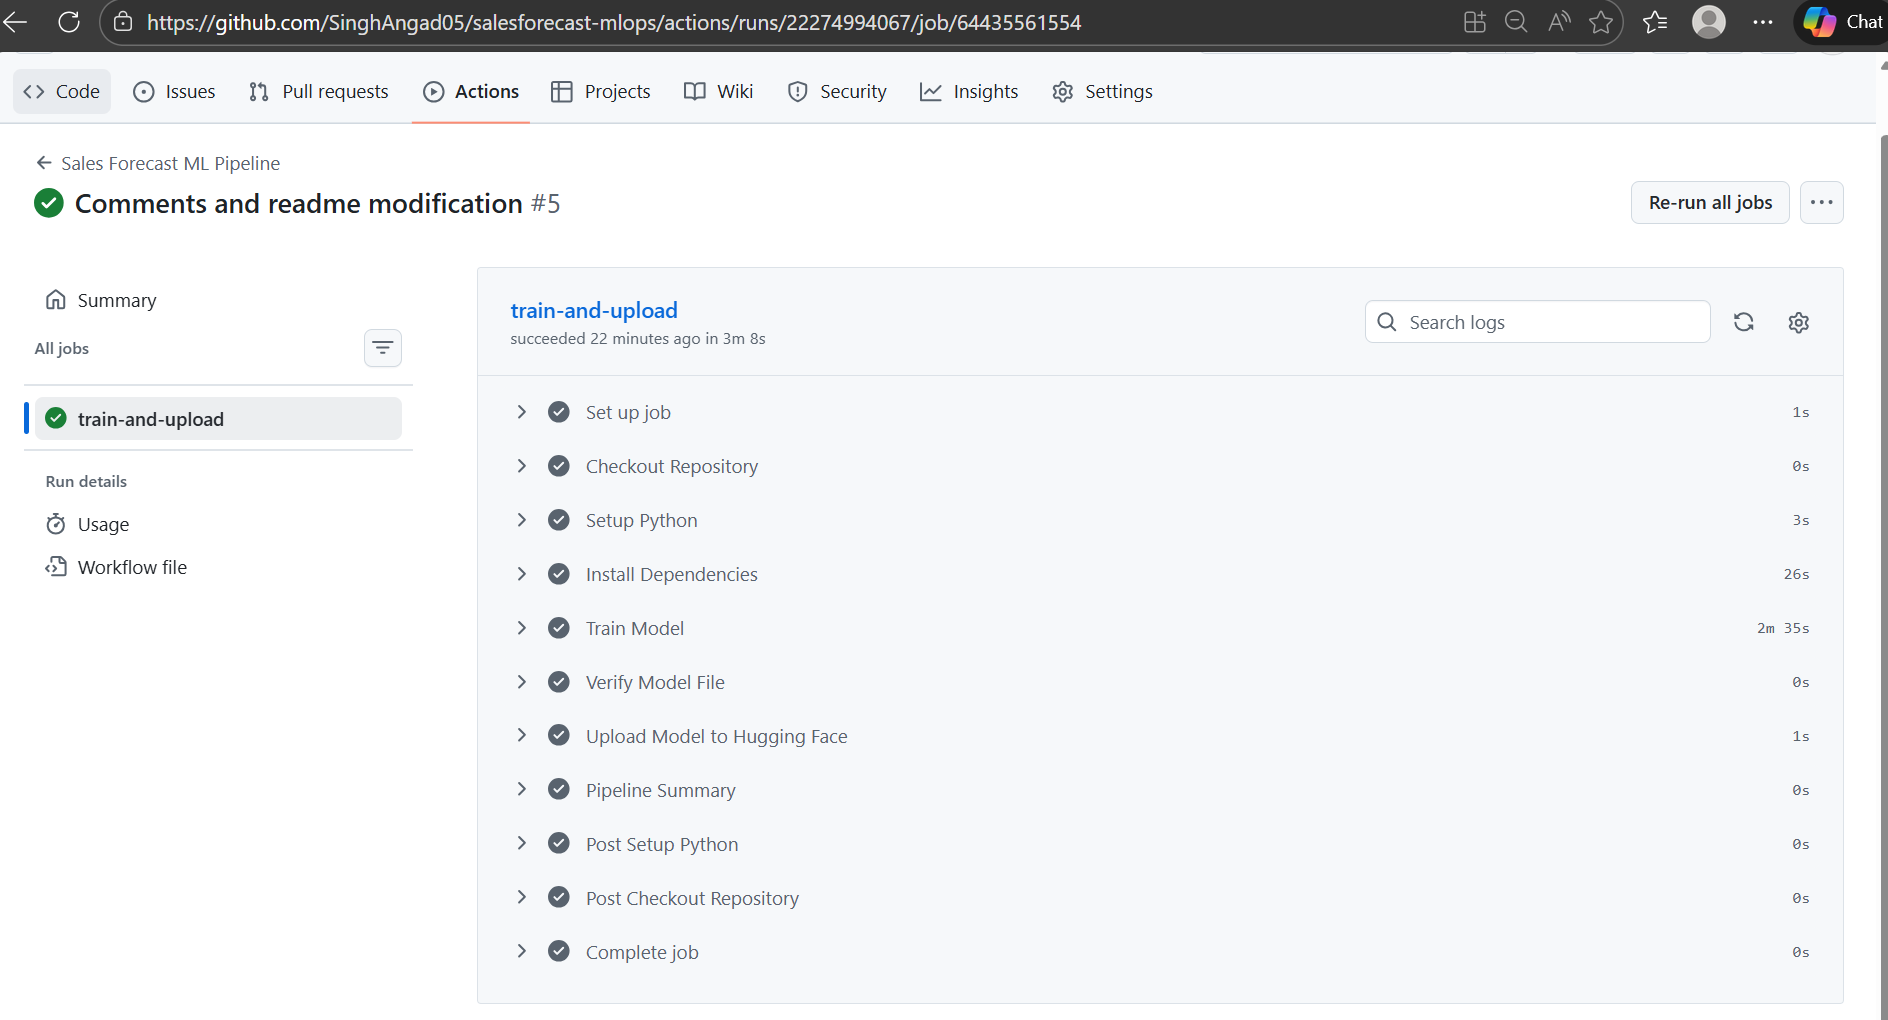

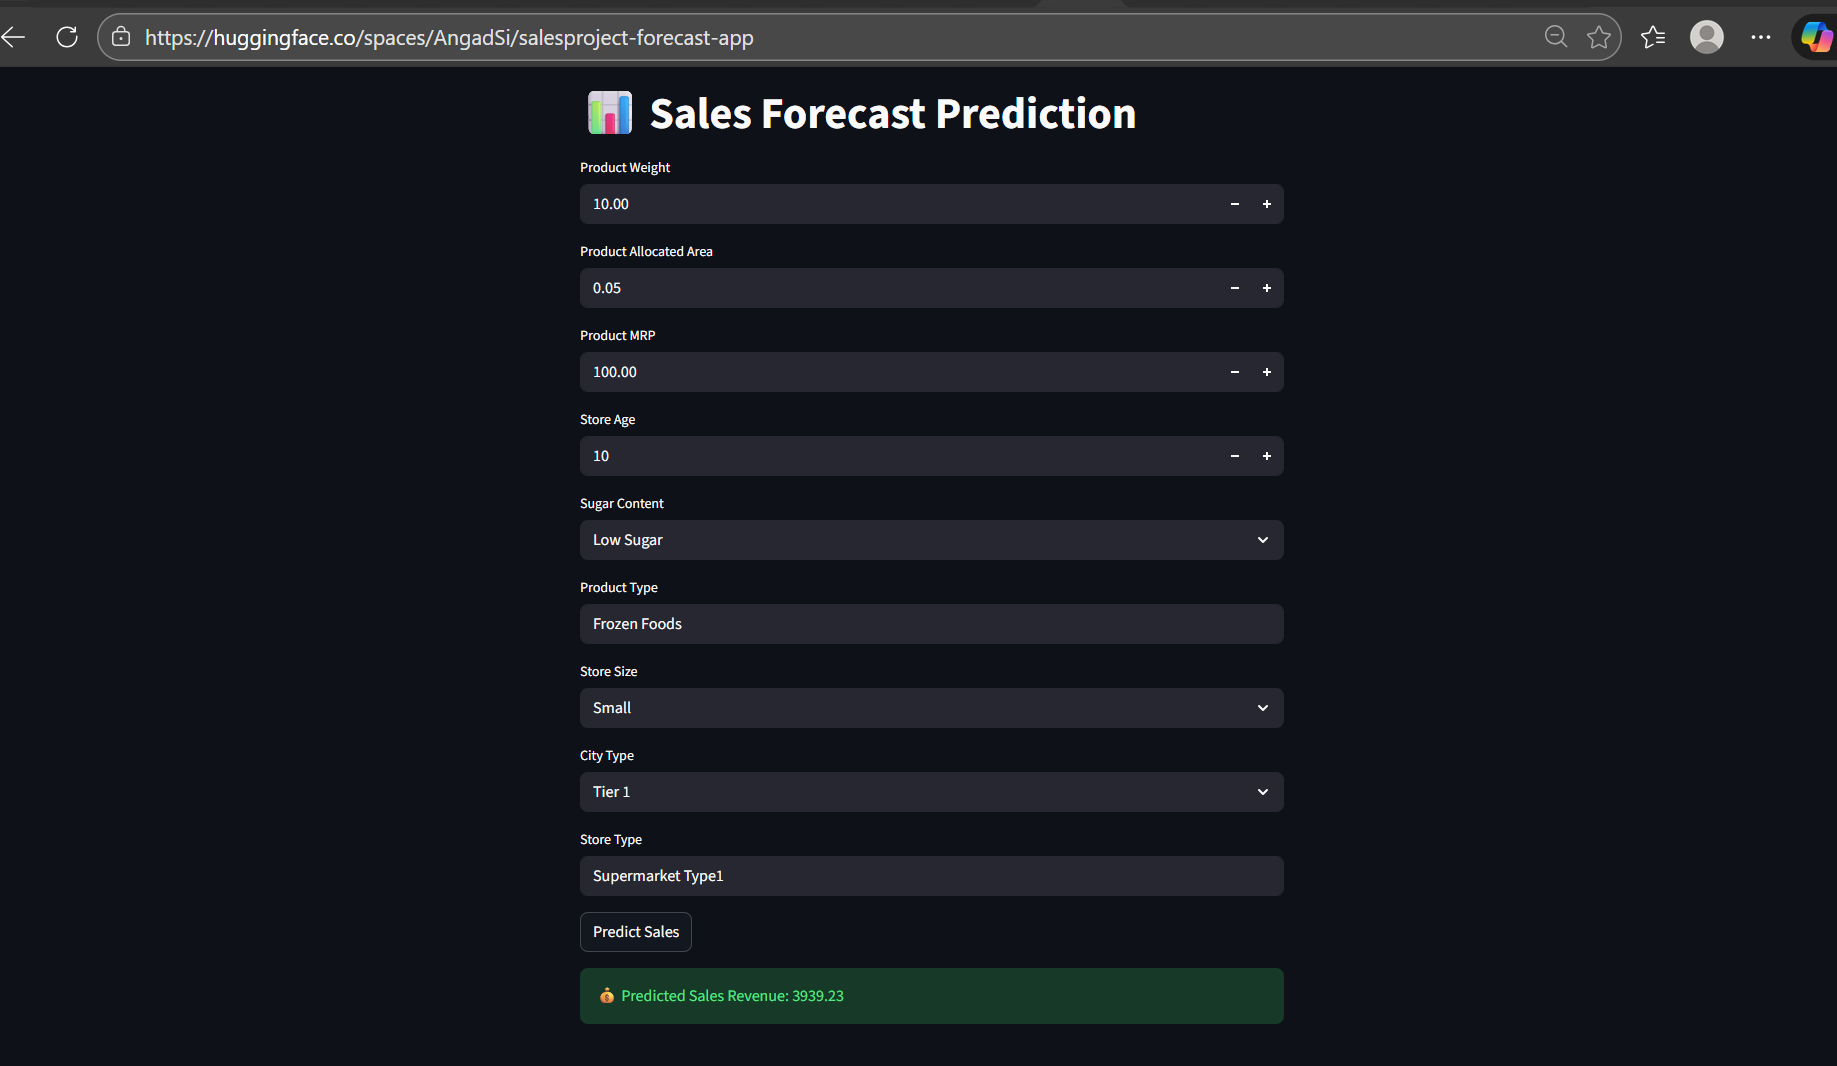